<div style="text-align: right;">
Regina Tamayo León<br>
Valeria Estefanía Milke Loera<br>
Santiago Alvarez Tostado Estrada
</div>

# **P01-: Predicción del Mercado Inmobiliario Americano**

### 1. Objetivos

**1.1 Objetivo General**: Analizar y comparar diferentes especificaciones de modelos de regresión lineal para explicar y predecir el precio de viviendas en Estados Unidos, evaluando el impacto de variables físicas, socioeconómicas y términos de interacción, así como el efecto de técnicas de regularización sobre la capacidad predictiva del modelo.

**1.2 Objetivos específicos**: 
- Explorar y limpiar el conjunto de datos 
- Construir tres arquitecturas de regresión lineal:
    1. Modelo basado únicamente en características físicas.
    2. Modelo que incorpora variables socioeconómicas y efectos por estado.
    3. Modelo que incluye interacción entre variables físicas y socioeconómicas.
- Implementar cuatro versiones para cada arquitectura: sin penalización (OLS), Ridge, Lasso y ElasticNet.
- Comparar el desempeño de los modelos mediante el coeficiente ($R^2$) en entrenamiento y prueba.
- Analizar la significancia estadística de los factores en el modelo seleccionado sin penalización.
__________________

### 2. Marco Teórico
**2.1 Regresión lineal**
La regresión lineal múltiple es una técnica estadística utilizada para modelar la relación entre una variable dependiente y un conjunto de variables independientes. Su objetivo es estimar cómo varía la variable respuesta en función de cambios en los predictores, bajo el supuesto de linealidad entre las variables. El modelo se expresa como:
$$Y = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + \dots + \beta_k X_k + \varepsilon$$
donde $\beta_0$ representa el intercepto, $\beta_i$ los coeficientes asociados a cada variable explicativa y $\varepsilon$ el término de error aleatorio. Los parámetros se estiman mediante el método de mínimos cuadrados ordinarios (OLS), que minimiza la suma de los errores cuadráticos entre los valores observados y los valores estimados por el modelo.
El coeficiente de determinación $R^2$ se utiliza como medida de ajuste, indicando la proporción de la variabilidad de la variable dependiente que es explicada por el modelo.

**2.2 Interacción de factores**

En algunos contextos, el efecto de una variable independiente sobre la variable dependiente puede depender del nivel de otra variable. En estos casos, se incorporan términos de interacción al modelo. Un término de interacción permite capturar efectos conjuntos entre dos variables y se construye como el producto de ambas.

**2.3 Significancia estadística**

La significancia de los coeficientes estimados se evalúa mediante pruebas de hipótesis individuales. Cada coeficiente se somete a una hipótesis nula que plantea que su valor es igual a cero. Si el valor p asociado es menor a un nivel de significancia de 0.05, se rechaza la hipótesis nula y se concluye que la variable tiene un efecto estadísticamente significativo sobre la variable dependiente. Por otro lado, de ser el valor p mayor a 0.05, no se rechaza la hipótesis nula y entonces se cocnluye que la variable no es significativa estadísticamente (pues su valor real podría ser 0) y que el resultado obtenido puede deberse al azar. En resumen, el análisis de significancia permite identificar aquellos factores que influyen de manera relevante en la determinación del precio de la vivienda y distinguirlos de aquellos cuyo efecto podría atribuirse al azar.

**2.4 Regularización**

Aunque el modelo de mínimos cuadrados ordinarios es ampliamente utilizado, puede presentar problemas cuando existe multicolinealidad o cuando el modelo incluye un gran número de variables. Para evitar esto, se emplean técnicas de regularización como Ridge, Lasso y ElasticNet.
La regresión Ridge incorpora una penalización basada en la norma cuadrática L2, lo que reduce la magnitud de los coeficientes sin eliminarlos completamente. Por su parte, Lasso utiliza una penalización basada en la norma absoluta L1, que puede llevar algunos coeficientes exactamente a cero, funcionando como un método de selección de variables. ElasticNet combina ambas penalizaciones, buscando un balance entre reducción de varianza y selección de variables. Esto permite evaluar si la inclusión de penalización mejora la capacidad de generalización del modelo frente a nuevos datos.
________________

### 3. Análisis del dataset 

**3.1 Origen del conjunto de datos**

El conjunto de datos utilizado en este proyecto proviene de registros de listados de viviendas en Estados Unidos correspondientes al año 2023. La información contiene datos estructurales, geográficos y socioeconómicos asociados a cada propiedad. El archivo empleado integra información relevante para el análisis del comportamiento del precio de las viviendas dentro del mercado residencial estadounidense.

**3.2 Contenido del dataset**

El dataset está conformado por 39,981 registros y 14 variables, cada una correspondiente a características específicas de las propiedades y su entorno. Entre las variables principales se incluyen:
- Price: Precio de la vivienda (variable dependiente)
- Beds: Número de habitaciones
- Baths: Número de baños
- Living Space: Superficie habitable de la propiedad
- State: Estado en el que se ubica la vivienda
- Zip Code Density: Densidad poblacional del área
- Median Household Income: Ingreso medio del hogar en el código postal
- Coordenadas geográficas
- Variables demográficas asociadas al código postal

**3.3 Información proporcionada por las muestras**

Las observaciones permiten analizar cómo el precio de una vivienda varía en función de:
- Sus dimensiones físicas (tamaño, número de habitaciones y baños)
- Su ubicación geográfica (estado y código postal)
- Las condiciones socioeconómicas del entorno (ingreso medio del hogar)
- Características demográficas del área (densidad poblacional)


**3.4 Transformaciones realizadas para el modelo de regresión**

Para poder implementar modelos de regresión lineal múltiple se realizarán las siguientes transformaciones:

1. Codificación de variables categóricas
2. Creación de variable de interacción --> Living Space×Median Household Income
3. Escalamiento de variables 
4. División del conjunto de datos
5. El conjunto de datos fue dividido de la siguiente manera: 70% para entrenamiento y 30% para prueba

**3.5 Resultados esperados de la regresión**

El análisis busca identificar los factores que influyen significativamente en el precio de las viviendas y comparar distintas arquitecturas de modelos para determinar cuál ofrece mejor capacidad explicativa y predictiva. Se pretende evaluar:

- La contribución de variables físicas.
- El efecto de variables socioeconómicas.
- El impacto de la interacción entre tamaño e ingreso.
- La utilidad de la regularización en términos de estabilidad del modelo.
__________________

**Carga y limpieza de datos**

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
import statsmodels.api as sm

df = pd.read_csv('American_Housing_Data_20231209.csv')
df.head()

,Zip Code,Price,Beds,Baths,Living Space,Address,City,State,Zip Code Population,Zip Code Density,County,Median Household Income,Latitude,Longitude
0,10013,3999000.0,2,3,1967,74 GRAND ST APT 3,New York,New York,29563,20967.9,New York,370046.0,40.72001,-74.00472
1,10013,3999000.0,2,3,1967,74 GRAND ST APT 3,New York,New York,29563,20967.9,New York,370046.0,40.72001,-74.00472
2,10014,1650000.0,1,1,718,140 CHARLES ST APT 4D,New York,New York,29815,23740.9,New York,249880.0,40.73407,-74.00601
3,10014,760000.0,3,2,1538,38 JONES ST,New York,New York,29815,23740.9,New York,249880.0,40.73407,-74.00601
4,10014,1100000.0,1,1,600,81 BEDFORD ST APT 3F,New York,New York,29815,23740.9,New York,249880.0,40.73407,-74.00601


In [8]:
df = df.dropna(subset=['Median Household Income'])

In [20]:
# Selección de estados principales para Dummies
top_states = df['State'].value_counts().nlargest(5).index
df_filtered = df[df['State'].isin(top_states)].copy()
df_final = pd.get_dummies(df_filtered, columns=['State'], drop_first=True)

# Creación de Interacción/Polinomial
df_final['Space_Income_Interaction'] = df_final['Living Space'] * df_final['Median Household Income']

**Definición de los 3 modelos**

In [10]:
# Modelo 1: Solo físico
m1_feats = ['Beds', 'Baths', 'Living Space']
# Modelo 2: Físico + Socioeconómico + Dummies
state_cols = [col for col in df_final.columns if 'State_' in col]
m2_feats = m1_feats + ['Median Household Income', 'Zip Code Density'] + state_cols
# Modelo 3: Modelo 2 + Interacción de Factores
m3_feats = m2_feats + ['Space_Income_Interaction']

modelos_lista = [m1_feats, m2_feats, m3_feats]
nombres_modelos = ["Modelo 1", "Modelo 2", "Modelo 3"]

final_results = []

**Ajuste de modelos**

In [11]:
for i, features in enumerate(modelos_lista):
    X = df_final[features]
    y = df_final['Price']
    
    # Split y Escalamiento
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
    scaler = StandardScaler()
    X_train_sc = scaler.fit_transform(X_train)
    X_test_sc = scaler.transform(X_test)
    
    # Versiones de Penalización
    versiones = {
        'Sin Penalización': LinearRegression(),
        'Ridge (L2)': Ridge(alpha=10),
        'Lasso (L1)': Lasso(alpha=100),
        'ElasticNet': ElasticNet(alpha=0.1)
    }
    
    for v_name, reg in versiones.items():
        reg.fit(X_train_sc, y_train)
        r2_tr = reg.score(X_train_sc, y_train)
        r2_te = reg.score(X_test_sc, y_test)
        
        final_results.append({
            'Arquitectura': nombres_modelos[i],
            'Penalización': v_name,
            'R2_Train': r2_tr,
            'R2_Test': r2_te
        })
        
        # Guardar coeficientes para el análisis de significancia (solo del OLS)
        if v_name == 'Sin Penalización' and i == 2:
            m3_ols_coefs = pd.Series(reg.coef_, index=features).sort_values(ascending=False)


**Tabla de resultados**

In [12]:
df_resultados = pd.DataFrame(final_results)
df_resultados

,Arquitectura,Penalización,R2_Train,R2_Test
0,Modelo 1,Sin Penalización,0.371760,0.278720
1,Modelo 1,Ridge (L2),0.371758,0.278698
2,Modelo 1,Lasso (L1),0.371760,0.278788
3,Modelo 1,ElasticNet,0.367792,0.274353
4,Modelo 2,Sin Penalización,0.522401,0.445521
5,Modelo 2,Ridge (L2),0.522400,0.445499
6,Modelo 2,Lasso (L1),0.522401,0.445612
7,Modelo 2,ElasticNet,0.518642,0.441321
8,Modelo 3,Sin Penalización,0.595752,0.648792
9,Modelo 3,Ridge (L2),0.595746,0.648132


**Visualización de R2**

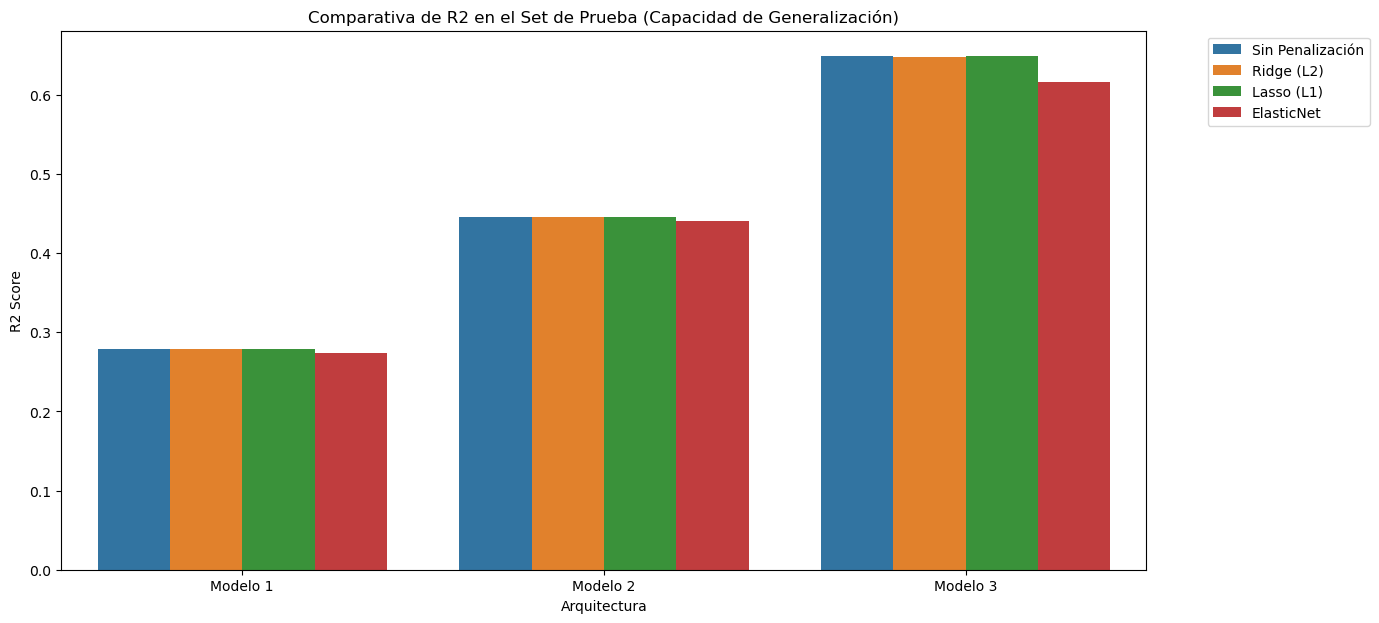

In [13]:
plt.figure(figsize=(14, 7))
sns.barplot(data=df_resultados, x='Arquitectura', y='R2_Test', hue='Penalización')
plt.title('Comparativa de R2 en el Set de Prueba (Capacidad de Generalización)')
plt.ylabel('R2 Score')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

**Análisis de significancia**

In [19]:
# Variables del Modelo 3
features = m3_feats

X = df_final[features]
y = df_final['Price']

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

X_train = X_train.astype(float)
X_train_sm = sm.add_constant(X_train)
model_sm = sm.OLS(y_train, X_train_sm).fit()

print(model_sm.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.596
Model:                            OLS   Adj. R-squared:                  0.595
Method:                 Least Squares   F-statistic:                     1870.
Date:                Sat, 21 Feb 2026   Prob (F-statistic):               0.00
Time:                        15:42:07   Log-Likelihood:            -1.8916e+05
No. Observations:               12697   AIC:                         3.783e+05
Df Residuals:                   12686   BIC:                         3.784e+05
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                   

Aquí analizamos cuáles factores pesan más en el precio de una casa. Space_Income_Interaction es positivo, confirma que el espacio habitable se vuelve mucho más caro en zonas de altos ingresos (validando nuestra hipótesis de interacción).

**Conclusión**

El objetivo general del estudio fue analizar y comparar distintos modelos de regresión lineal para explicar y predecir el precio de viviendas en Estados Unidos a partir de características estructurales y variables socioeconómicas del entorno. 

Los resultados muestran que el Modelo 3, el cual incorpora variables físicas, variables socioeconómicas, dummies por estado y un término de interacción entre superficie habitable e ingreso medio del hogar, presenta el mejor desempeño predictivo. Este modelo alcanzó un $R^2$ de 0.596, lo que indica que aproximadamente el 59.6% de la variabilidad del precio de las viviendas es explicada por las variables incluidas. En comparación, los Modelos 1 y 2 presentaron valores de $R^2$ considerablemente menores, lo que evidencia que la inclusión de variables socioeconómicas y efectos de interacción mejora sustancialmente la capacidad explicativa del modelo.

En cuanto a la regularización (Ridge, Lasso y ElasticNet), los resultados muestran que las versiones penalizadas no generaron mejoras significativas en el $R^2$ respecto al modelo sin penalización. Esto sugiere que el conjunto de variables no presenta problemas severos de sobreajuste ni multicolinealidad crítica que requieran corrección.

El análisis de significancia estadística mediante OLS indica que la mayoría de las variables incluidas en el Modelo 3 son estadísticamente significativas, puesto que presentan un p-value < 0.05. En particular:

- El término de interacción "Living spacexMedian Household Income" resultó altamente significativo, lo que sugiere que el efecto del tamaño de la vivienda sobre el precio depende del nivel de ingreso del área.
- Variables como ingreso medio del hogar, densidad poblacional y efectos por estado también muestran una influencia significativa en la determinación del precio.
- La variable Living Space de forma individual no resultó significativa (p = 0.66), lo cual indica que su efecto aislado no es estadísticamente distinto de cero una vez que se incluye la interacción.

En conjunto, los resultados permiten concluir que el precio de la vivienda no depende únicamente de sus características físicas, sino que está fuertemente condicionado por el contexto socioeconómico y por la interacción entre tamaño e ingreso del entorno.

Por lo tanto, el Modelo 3 sin penalización cumple mejor con el objetivo del estudio, ofreciendo una combinación adecuada entre capacidad explicativa, coherencia estadística y estabilidad predictiva.

**Referencias APA**

- American Housing Dataset. (2023). Kaggle. Recuperado de: https://www.kaggle.com/datasets/jeremylarcher/american-house-prices-and-demographics-of-top-cities?resource=download

- Pedregosa, F., et al. (2011). Scikit-learn: Machine Learning in Python. Journal of Machine Learning Research.

- James, G., Witten, D., Hastie, T., Tibshirani, R., & Taylor, J. (2023). An introduction to statistical learning: With applications in Python. Springer.